In [4]:
#imports

%cd ..
import torchtt as tntt
import torch as tn
from src.qtt_interpolation.utils import *
from src.qtt_interpolation.int_tools import *
from src.qtt_interpolation.qttnoise import *
import matplotlib.pyplot as plt
import numpy as np

%cd ./examples

/home/users/siddhartha.morales/TTinterpolation/QTT-polynomial-interpolation/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/nfs/users/siddhartha.morales/TTinterpolation/QTT-polynomial-interpolation
/nfs/users/siddhartha.morales/TTinterpolation/QTT-polynomial-interpolation/examples
/nfs/users/siddhartha.morales/TTinterpolation/QTT-polynomial-interpolation/examples


/home/users/siddhartha.morales/TTinterpolation/QTT-polynomial-interpolation/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


# Classic Perlin Noise

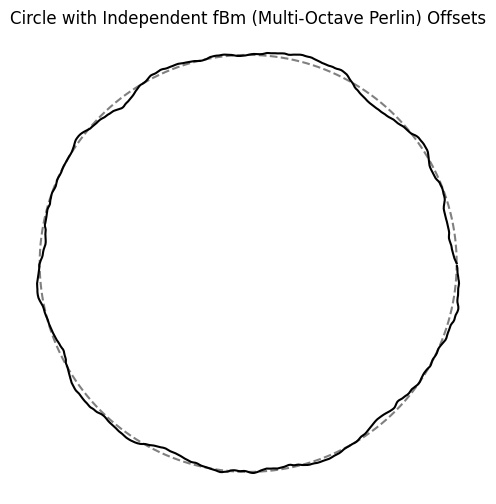

In [2]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

# ─── 1D Perlin‐noise implementation ──────────────────────────────────────────────
_perm = list(range(256))
random.seed(0)
random.shuffle(_perm)
_perm += _perm

def fade(t):
    return t * t * t * (t * (t * 6 - 15) + 10)

def lerp(a, b, t):
    return a + t * (b - a)

def grad(hash_val, x):
    return (1 if (hash_val & 1) == 0 else -1) * x

def perlin1d(x):
    x0 = math.floor(x)
    x1 = x0 + 1
    dx0 = x - x0
    dx1 = dx0 - 1.0
    h0 = _perm[x0 & 255]
    h1 = _perm[x1 & 255]
    dot0 = grad(h0, dx0)
    dot1 = grad(h1, dx1)
    u = fade(dx0)
    return lerp(dot0, dot1, u)

def fbm1d(x, octaves=4, persistence=0.5, lacunarity=2.0):
    """
    Fractal Brownian Motion in 1D:
      sum_{i=0..octaves-1} (perlin1d(x * frequency) * amplitude)
    normalized by the total amplitude.
    """
    total = 0.0
    amplitude = 1.0
    frequency = 1.0
    max_amp = 0.0
    for _ in range(octaves):
        total += perlin1d(x * frequency) * amplitude
        max_amp += amplitude
        amplitude *= persistence
        frequency *= lacunarity
    return total / max_amp  # roughly in [-1, 1]

# ─── Generate circle + independent X/Y noise offsets with octaves ───────────────
num_points = 600
radius     = 1.0

# Jitter amplitude for X and Y
amplitude_x = 0.1
amplitude_y = 0.1

# “Scale” for noise input (larger → gentler curves)
scale_x = 50.0
scale_y = 50.0

# Phase shift for Y‐noise
phase_shift = 37.0

# fBm parameters
octaves     = 5
persistence = 0.5
lacunarity  = 2.0

angles = np.linspace(0, 2 * math.pi, num_points, endpoint=False)
x_base = radius * np.cos(angles)
y_base = radius * np.sin(angles)

# Sample two independent fBm noise curves:
offsets_x = np.array([
    amplitude_x * fbm1d(i / scale_x, octaves, persistence, lacunarity)
    for i in range(num_points)
])
offsets_y = np.array([
    amplitude_y * fbm1d((i / scale_y) + phase_shift, octaves, persistence, lacunarity)
    for i in range(num_points)
])

x_noisy = x_base + offsets_x
y_noisy = y_base + offsets_y

# ─── Plot ───────────────────────────────────────────────────────────────────────
plt.figure(figsize=(6, 6))
# Perfect circle in dashed gray
plt.plot(x_base, y_base, linestyle='--', color='gray', label='Perfect Circle')
# Noisy circle in solid black
plt.plot(x_noisy, y_noisy, color='black', linewidth=1.5, label='Hand‐Drawn Circle (fbm)')

plt.gca().set_aspect('equal', 'box')
plt.axis('off')
plt.title("Circle with Independent fBm (Multi‐Octave Perlin) Offsets")

plt.savefig("./figs/circle_fbm.pdf",
            dpi=300,               # resolution in dots per inch
            bbox_inches="tight",   # trim excess whitespace
            transparent=False)     # set True for a transparent background


plt.show()


In [3]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import imageio

# ─── 1D Perlin‐noise implementation ──────────────────────────────────────────────
_perm = list(range(256))
random.seed(0)
random.shuffle(_perm)
_perm += _perm

def fade(t):
    return t * t * t * (t * (t * 6 - 15) + 10)

def lerp(a, b, t):
    return a + t * (b - a)

def grad(hash_val, x):
    return (1 if (hash_val & 1) == 0 else -1) * x

def perlin1d(x):
    x0 = math.floor(x)
    x1 = x0 + 1
    dx0 = x - x0
    dx1 = dx0 - 1.0
    h0 = _perm[x0 & 255]
    h1 = _perm[x1 & 255]
    dot0 = grad(h0, dx0)
    dot1 = grad(h1, dx1)
    u = fade(dx0)
    return lerp(dot0, dot1, u)

def fbm1d(x, octaves=4, persistence=0.5, lacunarity=2.0):
    """
    Fractal Brownian Motion in 1D:
      sum_{i=0..octaves-1} (perlin1d(x * frequency) * amplitude)
    normalized by the total amplitude.
    """
    total = 0.0
    amplitude = 1.0
    frequency = 1.0
    max_amp = 0.0
    for _ in range(octaves):
        total += perlin1d(x * frequency) * amplitude
        max_amp += amplitude
        amplitude *= persistence
        frequency *= lacunarity
    return total / max_amp  # roughly in [-1, 1]

# ─── Generate circle + independent X/Y noise offsets with octaves ───────────────
num_points = 600
radius     = 1.0

# Jitter amplitude for X and Y
amplitude_x = 0.08
amplitude_y = 0.08

# “Scale” for noise input (larger → gentler curves)
scale_x = 50.0
scale_y = 50.0

# Phase shift for Y‐noise
phase_shift = 37.0

# fBm parameters
octaves     = 4
persistence = 0.5
lacunarity  = 2.0

angles = np.linspace(0, 2 * math.pi, num_points, endpoint=False)
x_base = radius * np.cos(angles)
y_base = radius * np.sin(angles)

# Sample two independent fBm noise curves:
offsets_x = np.array([
    amplitude_x * fbm1d(i / scale_x, octaves, persistence, lacunarity)
    for i in range(num_points)
])
offsets_y = np.array([
    amplitude_y * fbm1d((i / scale_y) + phase_shift, octaves, persistence, lacunarity)
    for i in range(num_points)
])

x_noisy = x_base + offsets_x
y_noisy = y_base + offsets_y

# ─── Animate drawing the noisy circle ────────────────────────────────────────────
num_frames = 100
step = num_points // num_frames

frames = []
for frame_idx in range(1, num_frames + 1):
    end = frame_idx * step
    if frame_idx == num_frames:
        end = num_points
    
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(x_noisy[:end], y_noisy[:end], color='black', linewidth=1.5)
    ax.set_aspect('equal', 'box')
    ax.axis('off')
    ax.set_xlim(-radius - amplitude_x - 0.1, radius + amplitude_x + 0.1)
    ax.set_ylim(-radius - amplitude_y - 0.1, radius + amplitude_y + 0.1)

    fig.canvas.draw()
    image = np.frombuffer(fig.canvas.buffer_rgba(), dtype='uint8')
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (4,))
    frames.append(image)
    plt.close(fig)

# Save as GIF
gif_path = "./gifs/circle_draw.gif"
imageio.mimsave(gif_path, frames, fps=15)

gif_path


'./gifs/circle_draw.gif'

# 1D Perlin Noise with TN

## Drawings

In [5]:
#perlin parameters
scale =15
octaves = 3
snoise = 3
rnoise = 5
forder=3
eps=1e-6
H = 1/2
perlin = qttperlin(snoise, scale, octaves=octaves, persistance = H , r_noise = rnoise,sorder=forder,eps=eps)
perlinf = perlin.full().flatten().numpy()

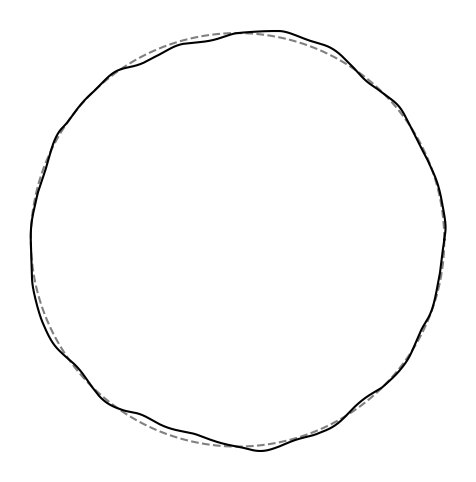

In [47]:
num_points = 2**scale
radius     = 1.0

# Jitter amplitude for X and Y
amplitude_x = 0.1
amplitude_y = 0.1

perlinx  = qttperlin(snoise, scale, octaves=octaves, persistance = H , r_noise = rnoise,sorder=forder,eps=eps)
perliny =  qttperlin(snoise, scale, octaves=octaves, persistance = H, r_noise = rnoise,sorder=forder,eps=eps)

x_base = radius * tntt.TT(qttcos(scale,a=2*np.pi))
y_base = radius * tntt.TT(qttsin(scale,a=2*np.pi))

# Sample two independent fBm noise curves:
offsets_x = amplitude_x*perlinx
offsets_y = amplitude_y*perliny
#offsets_x = amplitude_x*perlinf
#offsets_y = amplitude_y*perlinf
x_noisy = x_base + offsets_x
y_noisy = y_base + offsets_y
x_noisy = x_noisy.round(1e-6)
y_noisy = y_noisy.round(1e-6)

# ─── Plot ───────────────────────────────────────────────────────────────────────
plt.figure(figsize=(6, 6))
# Perfect circle in dashed gray
plt.plot(x_base.full().flatten(), y_base.full().flatten(), linestyle='--', color='gray', label='Perfect Circle')
# Noisy circle in solid black
plt.plot(x_noisy.full().flatten(), y_noisy.full().flatten(), color='black', linewidth=1.5, label='Hand‐Drawn Circle (fbm)')

plt.gca().set_aspect('equal', 'box')
plt.axis('off')
#plt.title("Circle with Fractal Noise Offsets")

plt.savefig("./figs/circle_1DPN_2.png",
            dpi=300,               # resolution in dots per inch
            bbox_inches="tight",   # trim excess whitespace
            transparent=False)     # set True for a transparent background


plt.show()




In [7]:
e0 = tntt.TT(tn.tensor([1,0],dtype=tn.float64))
e1 = tntt.TT(tn.tensor([0,1],dtype=tn.float64))
img = tntt.kron(e0,x_noisy) + tntt.kron(e1,y_noisy)
img = img.round(eps)
img

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 2, 4, 8, 11, 8, 5, 5, 5, 4, 4, 3, 3, 3, 2, 2, 1]

Device: cpu, dtype: torch.float64
#entries 772 compression 0.01177978515625

In [117]:
reps = 20
maxranks = []
scales = []
compressions = []

radius = 1
amplitude_x = 0.05
amplitude_y = 0.05
#perlin parameters
octaves = 3
snoise = 3
rnoise = 4
forder=3
eps=1e-6
H = 1/2

for i in range(8,21):
    print('doing...', i, end='\r')
    scale = i 
    x_base = radius * tntt.TT(qttcos(scale,a=2*np.pi))
    y_base = radius * tntt.TT(qttsin(scale,a=2*np.pi))
    for j in range(reps):
    
        perlinx  = qttperlin(snoise, scale, octaves=octaves, persistance = H , r_noise = rnoise,sorder=forder,eps=eps)
        perliny =  qttperlin(snoise, scale, octaves=octaves, persistance = H, r_noise = rnoise,sorder=forder,eps=eps)
        # Sample two independent fBm noise curves:
        offsets_x = amplitude_x*perlinx
        offsets_y = amplitude_y*perliny

        x_noisy = x_base + offsets_x
        y_noisy = y_base + offsets_y

        img = tntt.kron(e0,x_noisy) + tntt.kron(e1,y_noisy)
        img = img.round(eps)

        entries = sum([tn.numel(c) for c in img.cores])

        compression = entries / np.prod(np.array(img.N, dtype=np.float64))
            
        maxranks.append(np.max(img.R))
        scales.append(scale)
        compressions.append(compression)

# Create the DataFrame from the lists
df = pd.DataFrame({
    'scale': scales,
    'maxrank': maxranks,
    'compression': compressions
})
df.to_csv('circle_metrics.csv', index=False)

## Terrain

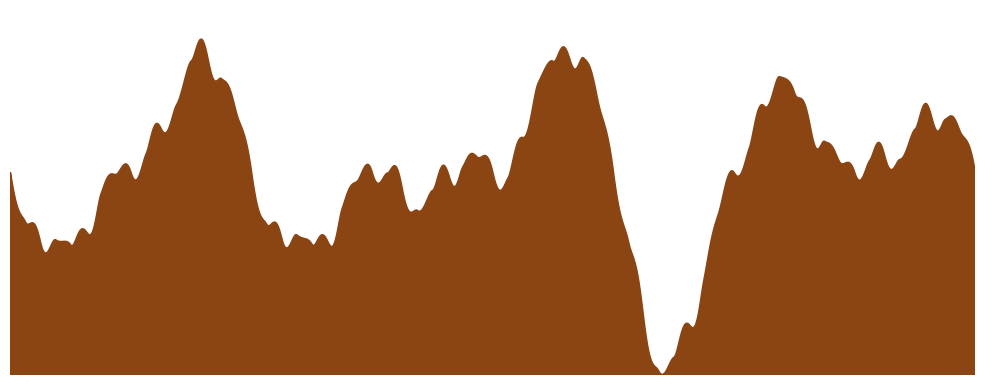

In [113]:
scale = 10
octaves = 4
snoise = 3
rnoise = 5
forder=3
eps=1e-6
H = 1/10
mpsm = qttperlin(snoise, scale, octaves=octaves, persistance = H , r_noise = rnoise,sorder=forder,eps=eps)
terrain_heights = mpsm.full().flatten()
terrain_heights -= terrain_heights.min()
# plot
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(2**scale)
ax.fill_between(x, terrain_heights, color='saddlebrown')
ax.set_ylim(0, terrain_heights.max() + 0.1)
ax.set_xlim(0, 2**scale - 1)

# remove entire axes (ticks, labels, spines)
ax.axis('off')

plt.tight_layout()

# save as PNG
fig.savefig('./figs/Pterrain.png', format='png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
reps = 20
maxranks = []
scales = []
compressions = []

radius = 1
amplitude_x = 0.05
amplitude_y = 0.05
#perlin parameters
octaves = 4
snoise = 3
rnoise = 5
forder=3
eps=1e-6
H = 1/10

for i in range(8,21):
    print('doing...', i, end='\r')
    scale = i 
    x_base = radius * tntt.TT(qttcos(scale,a=2*np.pi))
    y_base = radius * tntt.TT(qttsin(scale,a=2*np.pi))
    for j in range(reps):
    
        perlinx  = qttperlin(snoise, scale, octaves=octaves, persistance = H , r_noise = rnoise,sorder=forder,eps=eps)
        perliny =  qttperlin(snoise, scale, octaves=octaves, persistance = H, r_noise = rnoise,sorder=forder,eps=eps)
        # Sample two independent fBm noise curves:
        offsets_x = amplitude_x*perlinx
        offsets_y = amplitude_y*perliny

        x_noisy = x_base + offsets_x
        y_noisy = y_base + offsets_y

        img = tntt.kron(e0,x_noisy) + tntt.kron(e1,y_noisy)
        img = img.round(eps)

        entries = sum([tn.numel(c) for c in img.cores])

        compression = entries / np.prod(np.array(img.N, dtype=np.float64))
            
        maxranks.append(np.max(img.R))
        scales.append(scale)
        compressions.append(compression)

# Save the data to a CSV file
df = pd.DataFrame({
    'scale': scales,
    'maxrank': maxranks,
    'compression': compressions
})
df.to_csv('terrain_metrics.csv', index=False)

# Group by 'scale' and compute mean and std for 'compression' and 'maxrank'
grouped_t = df.groupby('scale').agg(
    compression_mean=('compression', 'mean'),
    compression_std=('compression', 'std'),
    maxrank_mean=('maxrank', 'mean'),
    maxrank_std=('maxrank', 'std')
).reset_index()




## Metrics

In [ ]:

# Group by 'scale' and compute mean and std for 'compression' and 'maxrank'
grouped = df.groupby('scale').agg(
    compression_mean=('compression', 'mean'),
    compression_std=('compression', 'std'),
    maxrank_mean=('maxrank', 'mean'),
    maxrank_std=('maxrank', 'std')
).reset_index()

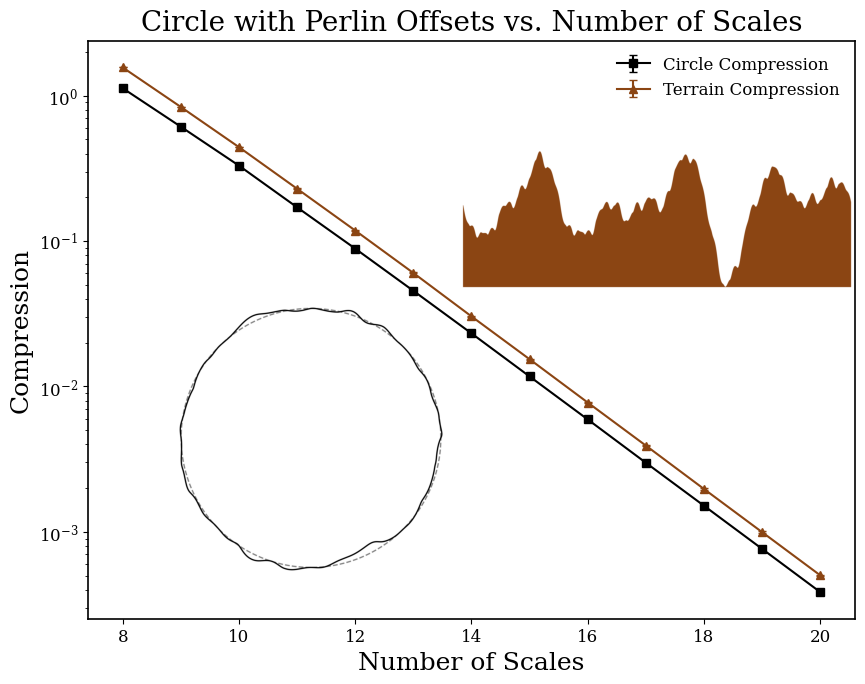

In [136]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.ticker import LogFormatterSciNotation

# 1) LaTeX style
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# 2) Main plot
fig, ax = plt.subplots(figsize=(3*3.3, 3*2.5))

# first series
ax.errorbar(
    grouped['scale'],
    grouped['compression_mean'],
    yerr=grouped['compression_std'],
    fmt='-s',
    color="#000000",
    capsize=3,
    label='Circle Compression'
)

# second series (from groupped_t)
ax.errorbar(
    grouped_t['scale'],
    grouped_t['compression_mean'],
    yerr=grouped_t['compression_std'],
    fmt='-^',
    color="#8B4513",
    capsize=3,
    label='Terrain Compression'
)

ax.set_xlabel('Number of Scales', fontsize=18)
ax.set_ylabel('Compression',      fontsize=18)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(LogFormatterSciNotation())

# legend
ax.legend(loc='upper right', fontsize=12, frameon=False)

# title (optional)
plt.title('Circle with Perlin Offsets vs. Number of Scales', pad=8, fontsize=20)

# thicken spines
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

# 3) Lower-left inset: manually in figure coords [left, bottom, width, height]
img1 = mpimg.imread('./figs/circle_1DPN.png')
axins1 = fig.add_axes([0.15, 0.15, 0.4, 0.4])  # adjust these four numbers
axins1.imshow(img1)
axins1.axis('off')
axins1.set_zorder(0)

# 4) Upper-right inset
img2 = mpimg.imread('./figs/Pterrain.png')
axins2 = fig.add_axes([0.5, 0.50, 0.40, 0.3])  # tweak these to move/resize
axins2.imshow(img2)
axins2.axis('off')
axins2.set_zorder(0)

# make sure main axes sits on top
ax.set_zorder(1)
ax.patch.set_visible(False)

# 5) Save
os.makedirs('./figs', exist_ok=True)
fig.savefig('./figs/p_metrics.pdf', format='pdf', bbox_inches='tight')

plt.show()
